<a href="https://colab.research.google.com/github/carolineolvs/am-t4-s1a2026/blob/main/census0417_amt4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline | Carregamento e Detecção de Anomalias [Fase 1 - credit_data]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Importar DataFrame [base_credit] - Descrição da base

In [4]:
base_census = pd.read_csv('/content/drive/MyDrive/am-t4/census.csv')

In [5]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Análise Exploratória de Anomalias [Alunos]

Possíveis idades negativas - (Incongruencias ou Impossibilidades) | resultante: Normalização

Possíveis ganhos negativos (Incongruencia ou impossibilidades) | resultante: Nulos

Possíveis nulidades  - (Dados nulos em bases) | resultante: Normalização

In [7]:
base_census.isnull().sum()

,0
age,0
workclass,0
final-weight,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Possibilidade de Dividade Negativa - (Incongruencia ou Impossibilidade) | resultante: Nula

# Pipeline | Vizualização de Dados e Anomalias [Fase 2 base_credit]

In [8]:
np.unique(base_census['income'], return_counts=True);

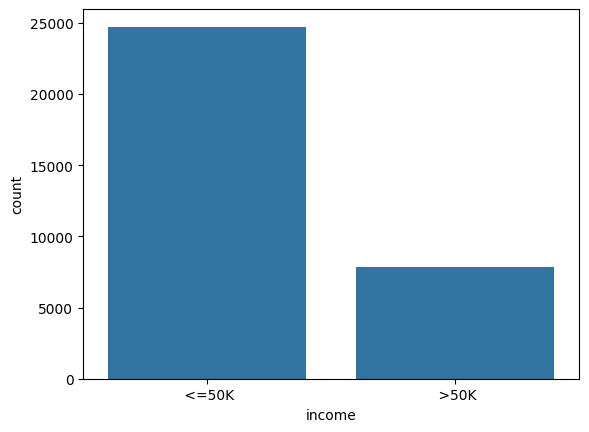

In [9]:
sns.countplot(x=base_census['income']);

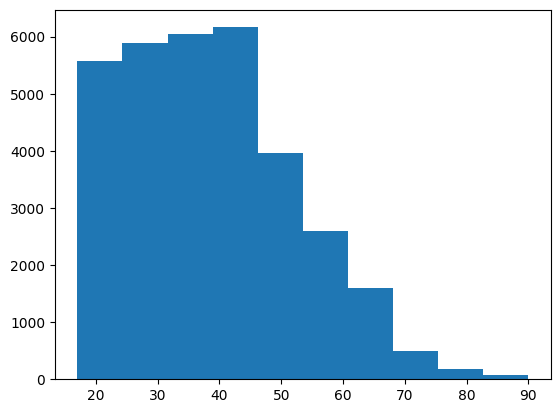

In [10]:
plt.hist(x=base_census['age']);

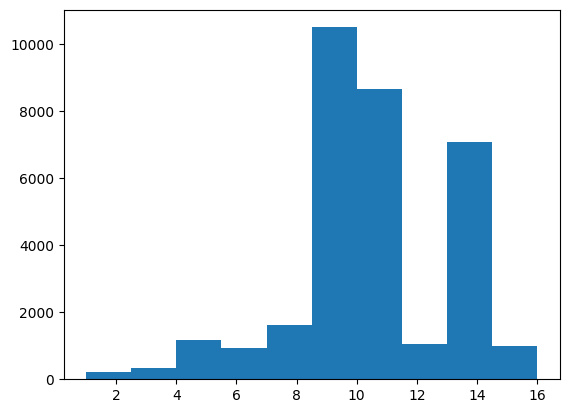

In [11]:
plt.hist(x=base_census['education-num'], bins=10);

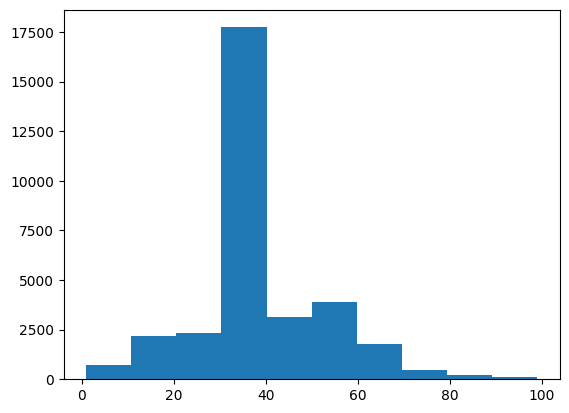

In [12]:
plt.hist(x=base_census['hour-per-week']);

In [17]:
grafico_grupo = px.treemap(base_census, path=['occupation', 'relationship', 'sex']);
grafico_grupo.show();

In [20]:
grafico_paralelo = px.parallel_categories(base_census, dimensions=['income', 'education-num']);
grafico_paralelo.show();

## Eixo de Alvos de Aprendizagem

In [15]:
np.unique(base_credit['default'], return_counts=True)

NameError: name 'base_credit' is not defined

In [ ]:
sns.countplot(
    x=base_credit['default'],
    hue=base_credit['default'],
    palette=['skyblue', 'salmon'],
    legend=False);

In [ ]:
plt.hist(x = base_credit['income'], edgecolor='black');

In [ ]:
plt.hist(x = base_credit['loan'], edgecolor='black');

In [ ]:
plt.hist(x = base_credit['age'], edgecolor='black');

Gráfico detecta área negativa de anomalias | confirmada em análise.

In [ ]:
grafico_credito = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color='default')
grafico_credito.show()


In [21]:
base_census.columns

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country',
       'income'],
      dtype='object')

In [23]:
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      dtype=object)

In [27]:
Y_census = base_census.iloc[:, 14].values

In [29]:
Y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

# Pipeline| Normalização de Dados [Fase 3]

In [ ]:
base_credit.mean()

In [ ]:
base_credit['age'].mean()

In [ ]:
base_credit['age'][base_credit['age'] > 0].mean()

In [ ]:
base_credit.loc[base_credit['age'] < 0, 'age'] = base_credit['age'][base_credit['age'] > 0].mean()

In [ ]:
base_credit.loc[base_credit['age']<0]

In [ ]:
base_credit[pd.isnull(base_credit['age'])]

In [ ]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True)

In [ ]:
base_credit.loc[base_credit['clientid'].isin([29,31,32])]

In [ ]:
type(base_credit)

In [30]:
from sklearn.preprocessing import LabelEncoder

In [32]:
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_matrial = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [33]:
label_encoder_workclass

LabelEncoder()

In [34]:
X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_matrial.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [36]:
X_census[:, 3]

array([39, 50, 38, ..., 58, 22, 52], dtype=object)

array([9, 9, 11, ..., 11, 11, 11], dtype=object)

# Pipeline | Previsores e Classes Neurais [Fase 4 - base_credit]

# Vetores Neurais de Classes

In [ ]:
X_credit = base_credit.iloc[:, 1:4].values

In [ ]:
X_credit

In [ ]:
type(X_credit)

In [ ]:
Y_credit = base_credit.iloc[:, 4].values

In [ ]:
Y_credit

In [ ]:
type(Y_credit)

## Organização de Escalas de Digestão

In [ ]:
X_credit[:, 0].min(), X_credit[:, 1].min(), X_credit[:, 2].min(),

In [ ]:
X_credit[:, 0].max(), X_credit[:, 1].max(), X_credit[:, 2].max(),

In [ ]:
(X_credit[:, 0].max() - X_credit[:, 0].min()), (X_credit[:, 1].max() - X_credit[:, 1].min()), (X_credit[:, 2].max() - X_credit[:, 2].min()),

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_credittreinamento, X_credit_teste, Y_credit_treinamento, Y_credit_teste = train_test_split(X_credit, Y_credit, test_size=0.15, random_state=0)

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/am-t4/credit.pkt', mode ='wb') as f:
  pickle.dump([X_credittreinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste], f)